# 1. Imports and Project Paths

In [1]:
from pathlib import Path
import sys

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
)

In [2]:
# Standard library imports
from pathlib import Path
from datetime import datetime
import sys

# Third-party imports
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# PROJECT_DIR is the parent folder of this notebook folder.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_DIR / "src"

# Add src/ to Python's import path so this notebook can use our reusable code.
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

TRAIN_DIR = PROJECT_DIR / "select_train_mini"
VAL_DIR = PROJECT_DIR / "select_val_mini"
TRAIN_JSON = TRAIN_DIR / "selected_train_mini.json"
VAL_JSON = VAL_DIR / "selected_val_mini.json"

RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"
FIGURES_DIR = PROJECT_DIR / "figures"

RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Training folder exists:", TRAIN_DIR.exists())
print("Validation folder exists:", VAL_DIR.exists())
print("Training JSON exists:", TRAIN_JSON.exists())
print("Validation JSON exists:", VAL_JSON.exists())

Project directory: e:\UNSW\9517\group work
Training folder exists: True
Validation folder exists: True
Training JSON exists: True
Validation JSON exists: True


In [8]:
# Reusable project helpers
from src.data_utils import load_selected_metadata, create_dataloaders, count_images_by_class
#from src.cnn_baseline import SimpleCNN
from src.resnet18_pretrained import build_resnet18_pretrained
from src.train_utils import train_model
from src.eval_utils import evaluate_model
from src.plot_utils import plot_training_history
from src.utils import set_seed, get_device, save_model_weights, append_experiment_log

In [7]:
# A fixed seed makes random operations more consistent between runs.
SEED = 42
set_seed(SEED)

# cuDNN benchmark can speed up training when image sizes are fixed.
torch.backends.cudnn.benchmark = True

device = get_device()

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
Device: NVIDIA GeForce RTX 4060 Laptop GPU


In [9]:
# Load selected JSON metadata for reproducibility and report tables.
train_meta, train_categories, train_images, train_annotations = load_selected_metadata(TRAIN_JSON)
val_meta, val_categories, val_images, val_annotations = load_selected_metadata(VAL_JSON)

train_counts = count_images_by_class(TRAIN_DIR)
val_counts = count_images_by_class(VAL_DIR)

summary = train_counts.merge(
    val_counts,
    on="class_name",
    suffixes=("_train", "_val"),
)

class_info = train_categories[[
    "category_id", "name", "common_name", "kingdom", "family", "genus", "image_dir_name"
]].rename(columns={"image_dir_name": "class_name", "name": "species_name"})

summary = class_info.merge(summary, on="class_name", how="left")

print("Number of classes:", len(summary))
print("Total train images:", summary["image_count_train"].sum())
print("Total validation images:", summary["image_count_val"].sum())

display(summary.head())
display(summary[["image_count_train", "image_count_val"]].describe())

Number of classes: 900
Total train images: 45000
Total validation images: 9000


,category_id,species_name,common_name,kingdom,family,genus,class_name,image_count_train,image_count_val
0,0,Lumbricus terrestris,Common Earthworm,Animalia,Lumbricidae,Lumbricus,00000_Animalia_Annelida_Clitellata_Haplotaxida...,50,10
1,1,Sabella spallanzanii,Mediterranean Fanworm,Animalia,Sabellidae,Sabella,00001_Animalia_Annelida_Polychaeta_Sabellida_S...,50,10
2,2,Serpula columbiana,Serpula columbiana,Animalia,Serpulidae,Serpula,00002_Animalia_Annelida_Polychaeta_Sabellida_S...,50,10
3,3,Spirobranchus cariniferus,Blue Tube Worm,Animalia,Serpulidae,Spirobranchus,00003_Animalia_Annelida_Polychaeta_Sabellida_S...,50,10
4,4,Eratigena duellica,Giant House Spider,Animalia,Agelenidae,Eratigena,00004_Animalia_Arthropoda_Arachnida_Araneae_Ag...,50,10


,image_count_train,image_count_val
count,900.0,900.0
mean,50.0,10.0
std,0.0,0.0
min,50.0,10.0
25%,50.0,10.0
50%,50.0,10.0
75%,50.0,10.0
max,50.0,10.0


In [10]:
# These settings can be adjusted for speed or accuracy.
# For RTX 4060, batch size 64 is usually a reasonable starting point.
IMAGE_SIZE = 224
BATCH_SIZE = 128 # But after we test, we can achieve to 128 to work faster
NUM_WORKERS = 4  
train_dataset, val_dataset, train_loader, val_loader = create_dataloaders(
    train_dir=TRAIN_DIR,
    val_dir=VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Number of classes:", num_classes)
print("First class:", train_dataset.classes[0])

Train samples: 45000
Validation samples: 9000
Number of classes: 900
First class: 00000_Animalia_Annelida_Clitellata_Haplotaxida_Lumbricidae_Lumbricus_terrestris


In [11]:
MODEL_PATH = PROJECT_DIR / "models" / "resnet181e-4_pretrained_best.pth"


model = build_resnet18_pretrained(
    num_classes=num_classes
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [12]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [13]:
cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[ 7  0  0 ...  0  0  0]
 [ 0 10  0 ...  0  0  0]
 [ 0  1  4 ...  0  0  0]
 ...
 [ 0  0  0 ...  3  0  0]
 [ 0  0  0 ...  0  1  0]
 [ 0  0  0 ...  0  0  3]]


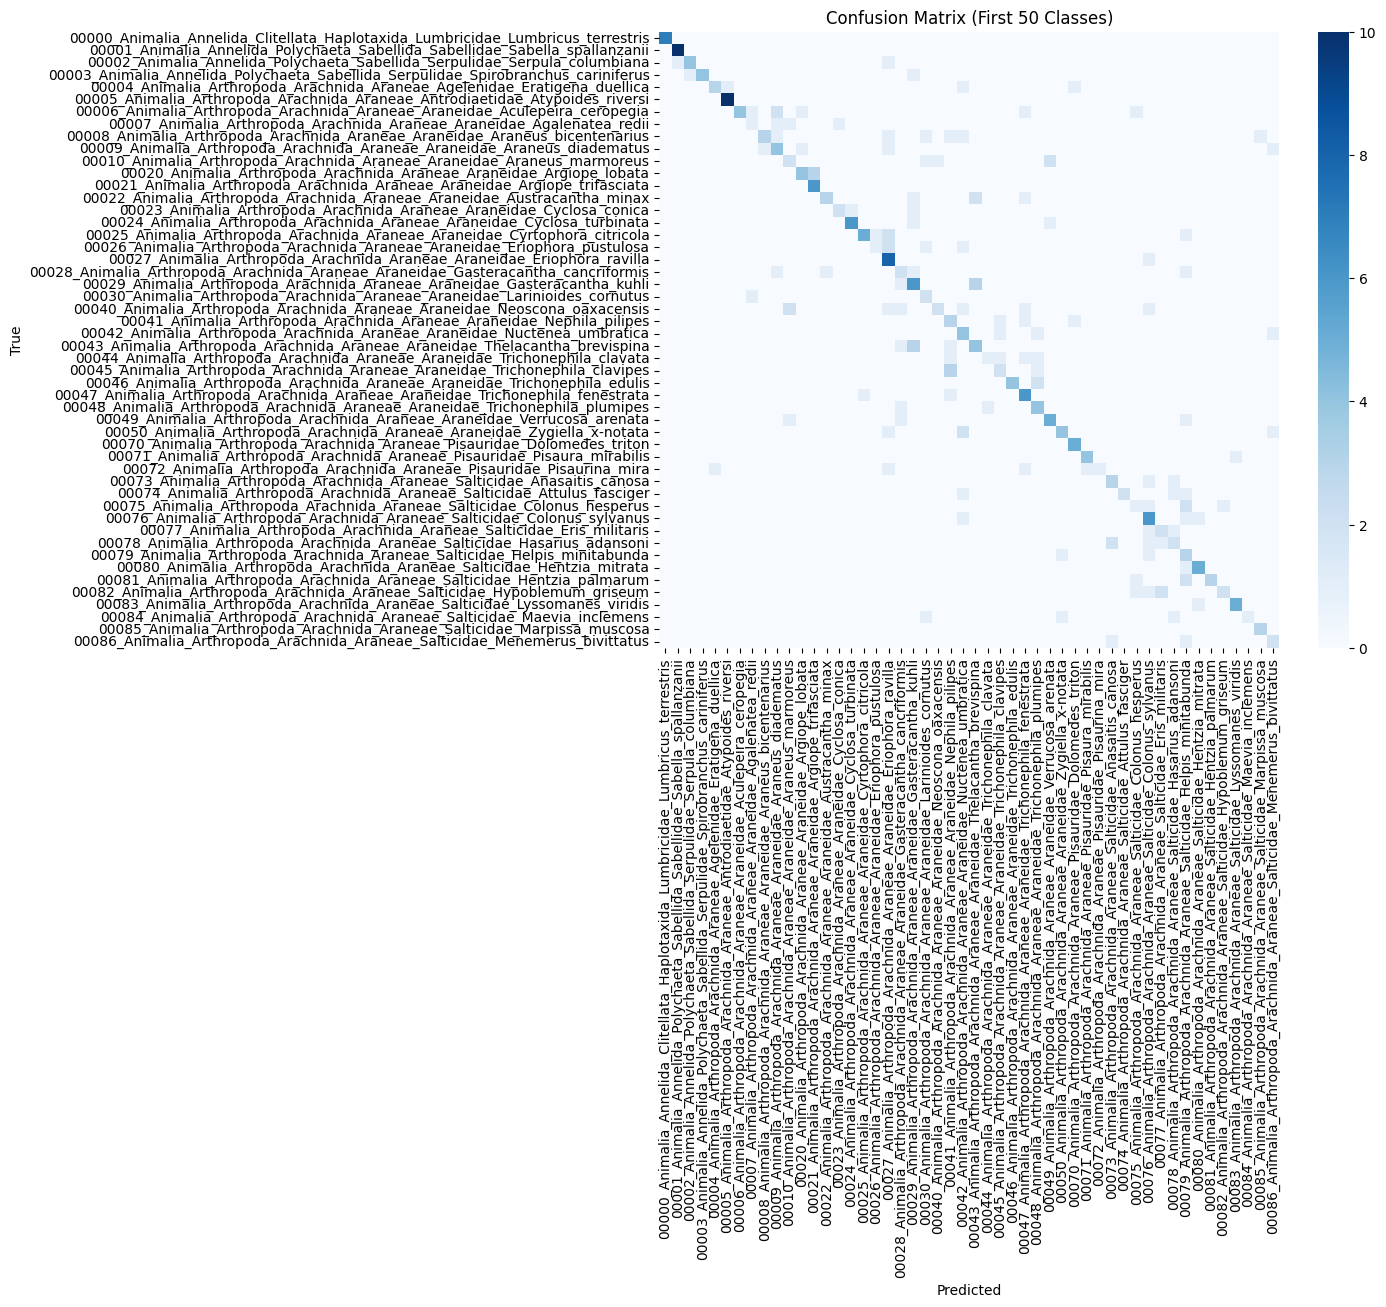

In [14]:
n = 50

plt.figure(figsize=(10,8))

sns.heatmap(
    cm[:n, :n],
    cmap="Blues",
    xticklabels=class_names[:n],
    yticklabels=class_names[:n],
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (First {n} Classes)")

plt.xticks(rotation=90)

plt.show()

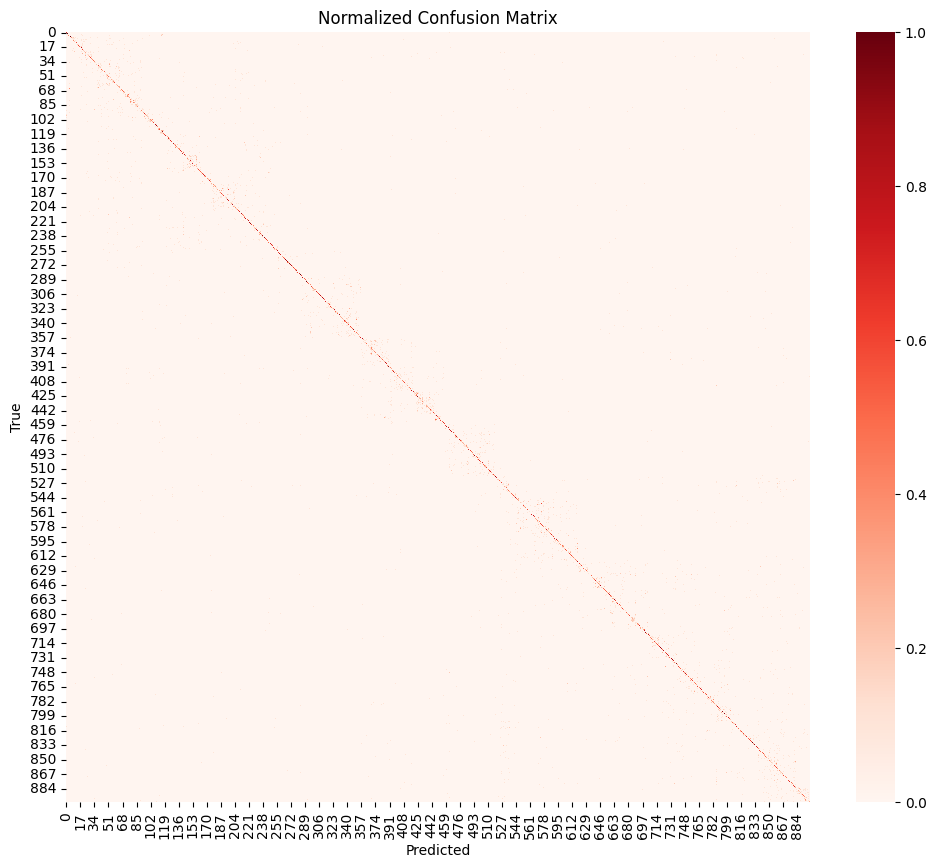

In [15]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm_norm,
    cmap="Reds",
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")

plt.show()

C:\Users\mr.han\AppData\Local\Temp\ipykernel_41704\261754221.py:42: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


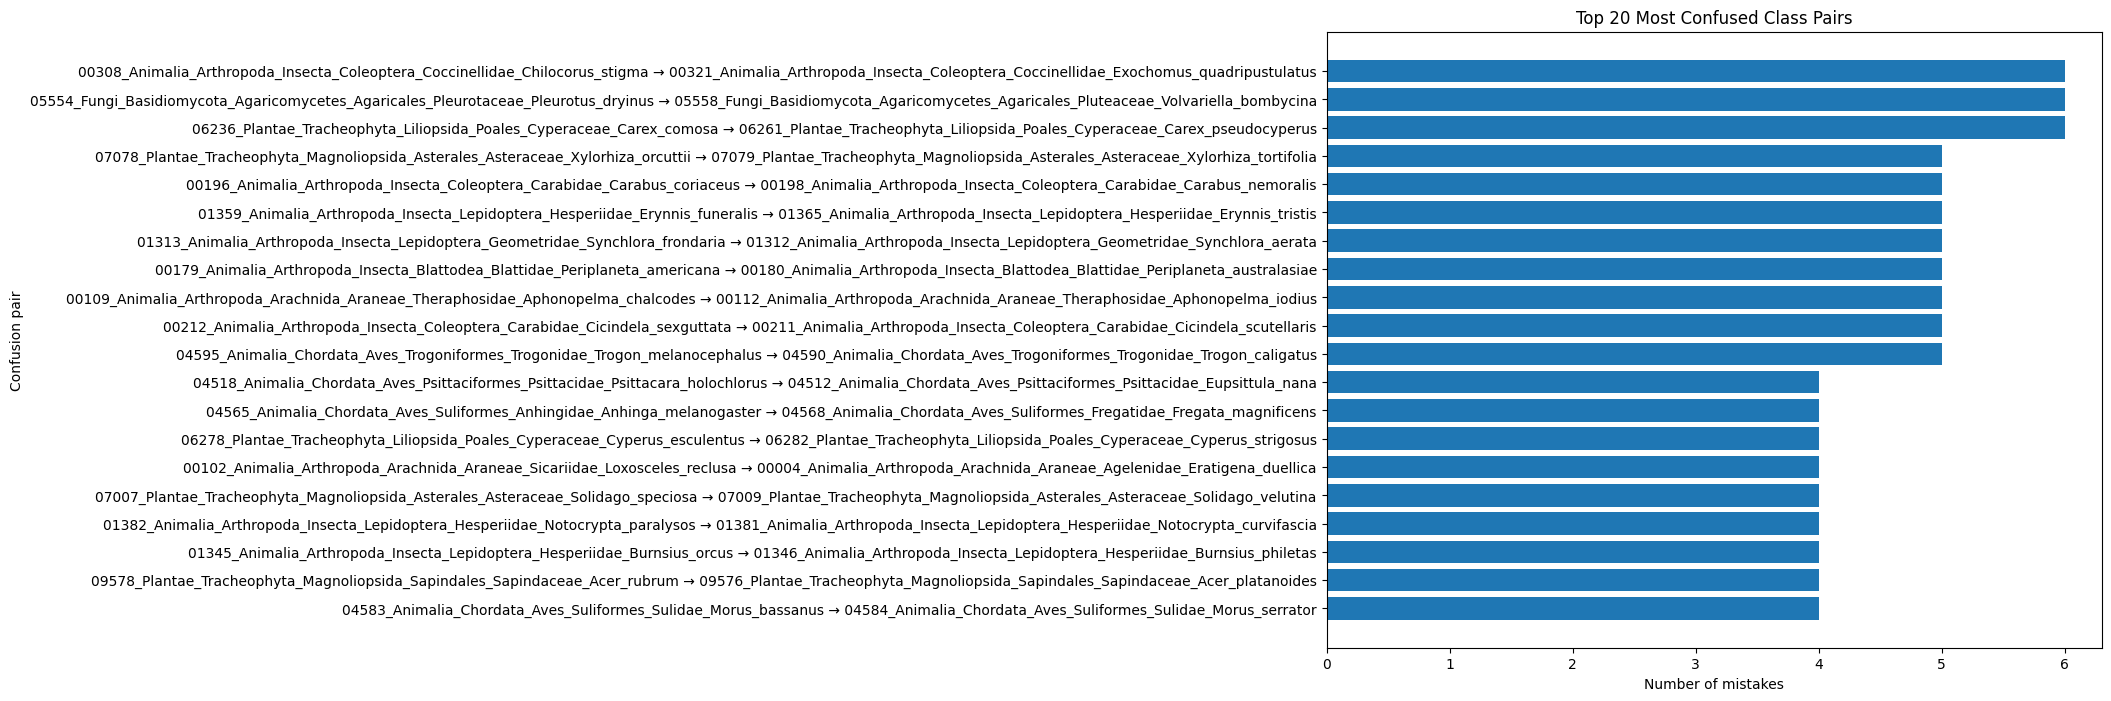

In [16]:
import numpy as np
import matplotlib.pyplot as plt


cm_error = cm.copy()
np.fill_diagonal(cm_error, 0)

top_n = 20

flat_indices = np.argsort(cm_error.ravel())[-top_n:][::-1]

rows, cols = np.unravel_index(
    flat_indices,
    cm_error.shape
)


labels = [
    f"{class_names[r]} → {class_names[c]}"
    for r, c in zip(rows, cols)
]

values = [
    cm_error[r, c]
    for r, c in zip(rows, cols)
]


plt.figure(figsize=(10,8))

plt.barh(
    labels[::-1],
    values[::-1]
)

plt.xlabel("Number of mistakes")
plt.ylabel("Confusion pair")
plt.title(
    f"Top {top_n} Most Confused Class Pairs"
)

plt.tight_layout()
plt.show()

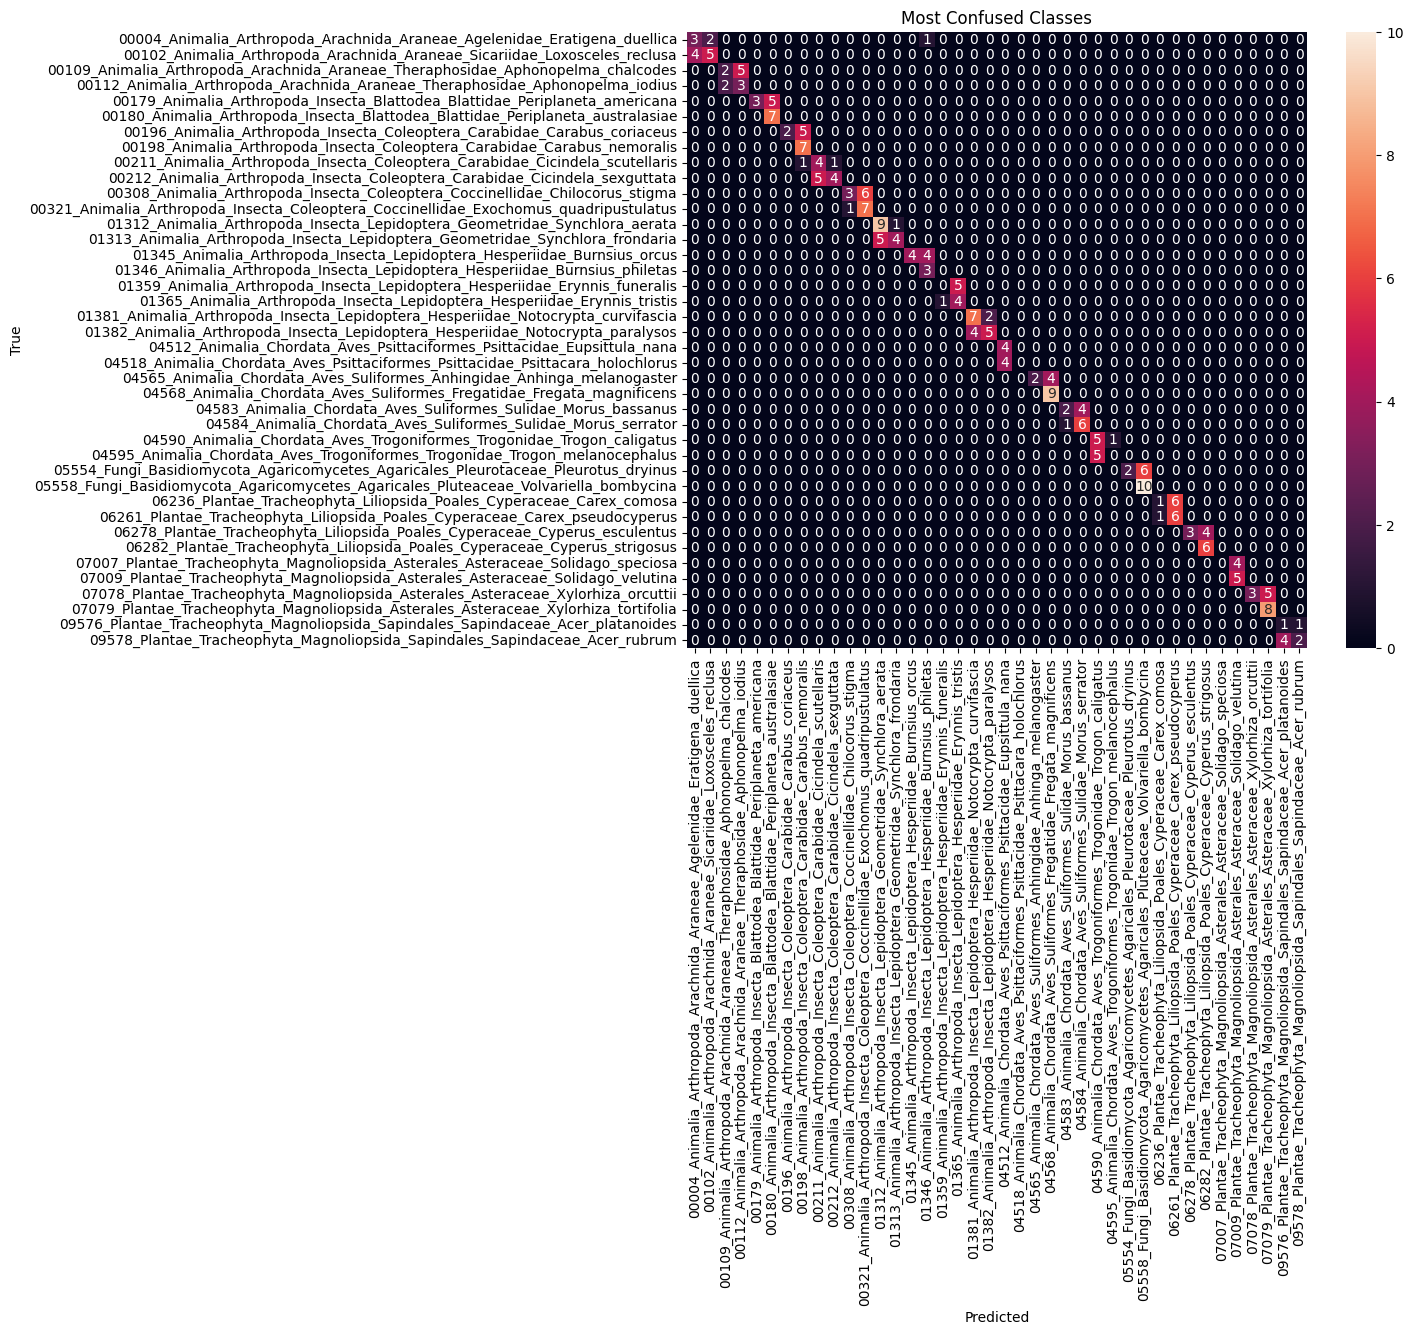

In [17]:
top_classes = np.unique(
    np.concatenate([rows, cols])
)

small_cm = cm[
    np.ix_(top_classes, top_classes)
]


plt.figure(figsize=(10,8))

sns.heatmap(
    small_cm,
    annot=True,
    fmt="d",
    xticklabels=[
        class_names[i] for i in top_classes
    ],
    yticklabels=[
        class_names[i] for i in top_classes
    ],
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Most Confused Classes")

plt.xticks(rotation=90)

plt.show()

In [18]:
print("Accuracy:", accuracy_score(all_labels, all_preds))

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))

Accuracy: 0.4552222222222222
                                                                                                     precision    recall  f1-score   support

                    00000_Animalia_Annelida_Clitellata_Haplotaxida_Lumbricidae_Lumbricus_terrestris       0.54      0.70      0.61        10
                       00001_Animalia_Annelida_Polychaeta_Sabellida_Sabellidae_Sabella_spallanzanii       0.77      1.00      0.87        10
                         00002_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Serpula_columbiana       0.44      0.40      0.42        10
                  00003_Animalia_Annelida_Polychaeta_Sabellida_Serpulidae_Spirobranchus_cariniferus       0.67      0.40      0.50        10
                          00004_Animalia_Arthropoda_Arachnida_Araneae_Agelenidae_Eratigena_duellica       0.21      0.30      0.25        10
                       00005_Animalia_Arthropoda_Arachnida_Araneae_Antrodiaetidae_Atypoides_riversi       0.77      1.00    

e:\anaconda\envs\UNSW9517\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\anaconda\envs\UNSW9517\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\anaconda\envs\UNSW9517\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
